<a href="https://colab.research.google.com/github/Kainat-Murtaza/DevelopersHub-DataScience-Internship/blob/main/Phase2_Business_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 5: Business Dashboard - Sales & Profit Analysis

 Goal: Create a comprehensive dashboard for analyzing sales,
   profit, and segment-wise performance.

 STEP 1: Loading and Preparing Sales Data
--------------------------------------------------
Creating realistic sales data similar to Global Superstore dataset...
 Data loaded successfully!
   • Total transactions: 5,000
   • Date range: 2024-01-01 to 2024-12-30
   • Total sales: $6,036,710
   • Total profit: $1,218,501
   • Unique customers: 3,845

 STEP 2: KEY PERFORMANCE INDICATORS (KPIs)

──────────────────────────────────────────────────
 TOTAL SALES:          $6,036,710
 TOTAL PROFIT:         $1,218,501
 PROFIT MARGIN:        20.2%
 AVERAGE DISCOUNT:     6.3%
 TOTAL ORDERS:         5,000
 AVG ORDER VALUE:      $1,207
 TOTAL ITEMS SOLD:     25,351
 AVG PROFIT PER ORDER: $244
──────────────────────────────────────────────────
 Great profit margin! Above 20% is excellent.

 STEP 3: Generating Dashboard Visualizations
-----------

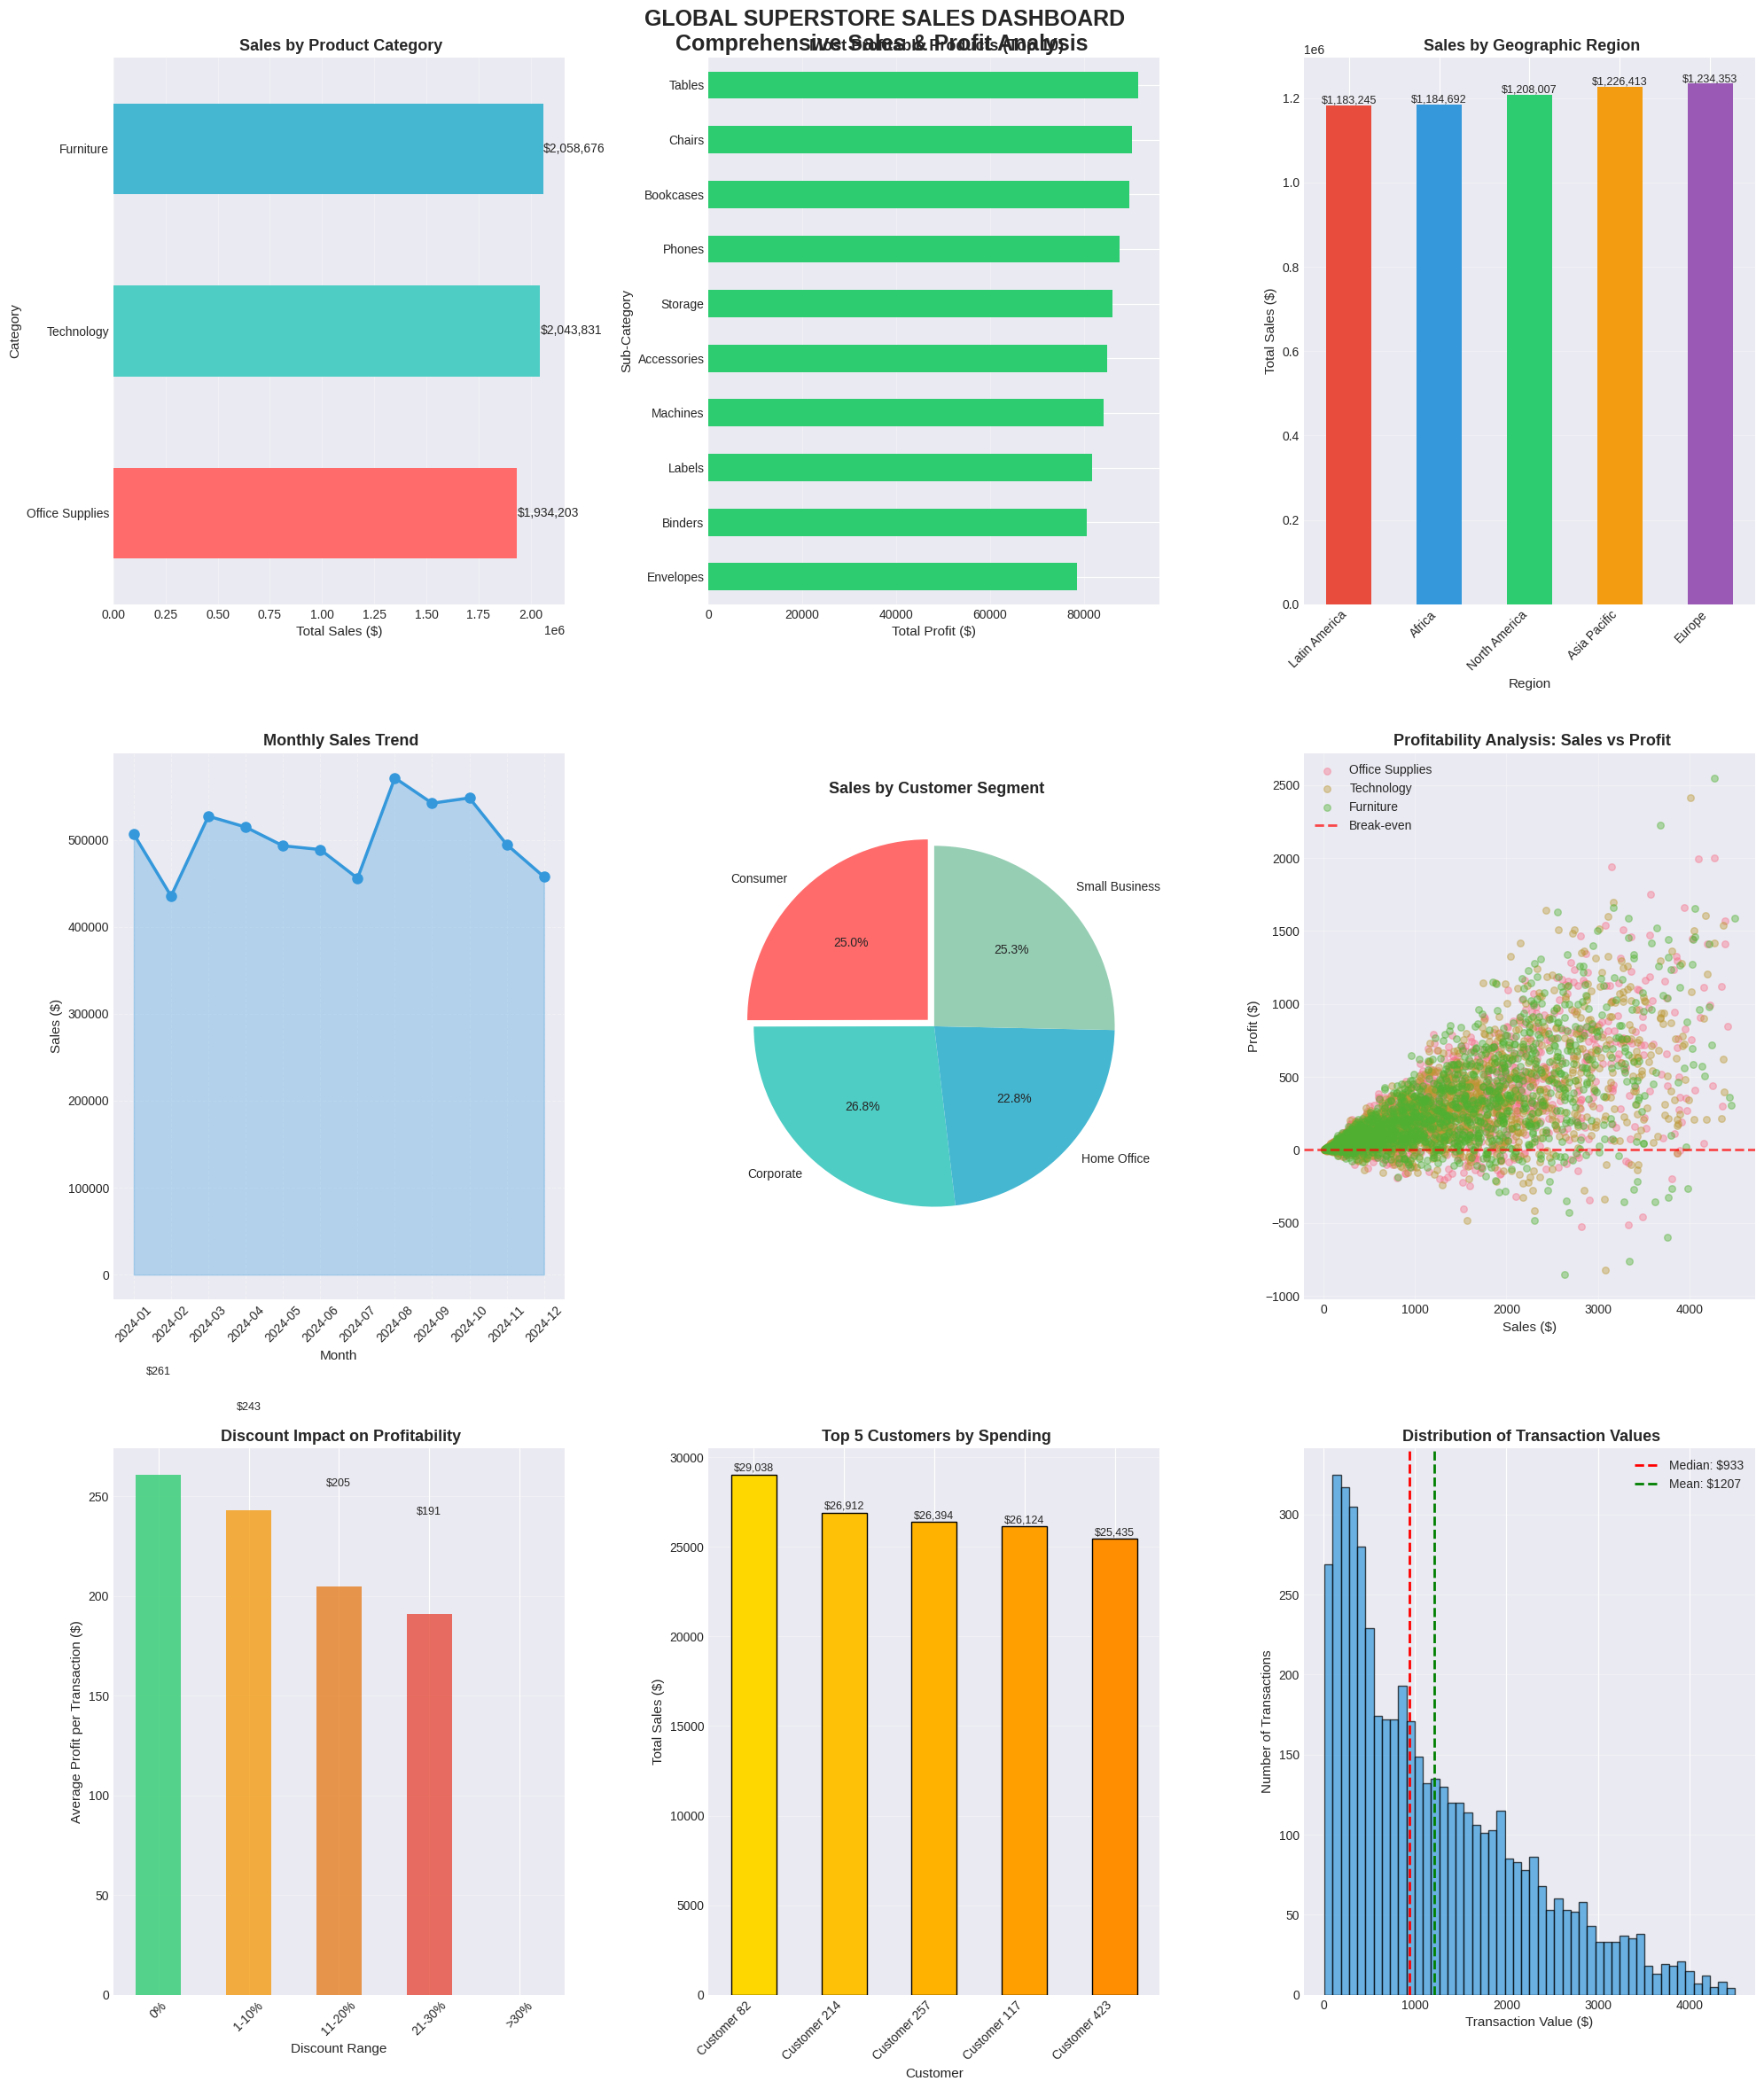

 Dashboard generated successfully!
   Saved as: task5_dashboard.png

 STEP 4: Business Insights & Recommendations

 KEY FINDINGS FROM THE DATA:

 WHAT'S WORKING WELL:
   • Technology category generates $406,712 in profit (highest among categories)
   • Corporate customers have the highest average order value
   • Europe is your best-performing region
   • Transactions with 0% discount are most profitable ($261 avg profit)

 AREAS NEEDING ATTENTION:
   • Discounts over 20% reduce profit by nan%
   • Furniture category has lower margins than Technology
   • Latin America region is underperforming
   • Some customers haven't purchased recently (consider retention campaigns)

 ACTIONABLE RECOMMENDATIONS:

1. **PRODUCT STRATEGY:**
   → Increase marketing budget for Technology products
   → Review pricing strategy for Furniture category
   → Promote top 5 most profitable sub-categories more heavily

2. **DISCOUNT STRATEGY:**
   → Limit discounts to 15% or less for most products
   → Reserve 

In [1]:
"""
Task 5: Business Dashboard
Data Science & Analytics Internship - DevelopersHub Corporation

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for professional-looking charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("TASK 5: Business Dashboard - Sales & Profit Analysis")
print("="*70)
print("\n Goal: Create a comprehensive dashboard for analyzing sales,")
print("   profit, and segment-wise performance.")
print("="*70)

# ============================================================================
# STEP 1: LOAD AND PREPARE THE DATA
# ============================================================================
print("\n STEP 1: Loading and Preparing Sales Data")
print("-" * 50)
print("Creating realistic sales data similar to Global Superstore dataset...")

np.random.seed(42)
n_records = 5000

# Define product categories (mirroring a real retail store)
categories = {
    'Technology': ['Phones', 'Accessories', 'Copiers', 'Machines', 'Computers'],
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings', 'Supplies'],
    'Office Supplies': ['Paper', 'Binders', 'Storage', 'Envelopes', 'Labels']
}

# Geographic regions for global analysis
regions = {
    'North America': ['USA', 'Canada', 'Mexico'],
    'Europe': ['UK', 'Germany', 'France', 'Spain', 'Italy'],
    'Asia Pacific': ['Australia', 'Japan', 'China', 'India', 'Singapore'],
    'Latin America': ['Brazil', 'Argentina', 'Colombia', 'Chile'],
    'Africa': ['South Africa', 'Nigeria', 'Egypt', 'Kenya']
}

# Customer segments (typical in retail analytics)
segments = ['Consumer', 'Corporate', 'Home Office', 'Small Business']
shipping_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

# Generate the data
data = []
for i in range(n_records):
    # Geographic info
    region = np.random.choice(list(regions.keys()))
    country = np.random.choice(regions[region])

    # Product info
    category = np.random.choice(list(categories.keys()))
    sub_category = np.random.choice(categories[category])

    # Customer info
    segment = np.random.choice(segments)
    customer_id = f"CG-{np.random.randint(1000, 9999)}"
    customer_name = f"Customer {np.random.randint(1, 500)}"

    # Order dates (within 2024)
    order_date = datetime(2024, 1, 1) + timedelta(days=np.random.randint(0, 365))
    ship_date = order_date + timedelta(days=np.random.randint(1, 10))
    ship_mode = np.random.choice(shipping_modes)

    # Sales metrics with realistic patterns
    quantity = np.random.randint(1, 10)
    unit_price = np.random.uniform(5, 500)
    sales = quantity * unit_price

    # Profit with some loss-making transactions (realistic!)
    profit_margin = np.random.normal(0.20, 0.15)
    profit = sales * profit_margin
    discount = np.random.choice([0, 0.1, 0.15, 0.2, 0.25, 0.3],
                                p=[0.6, 0.15, 0.1, 0.08, 0.05, 0.02])

    # Apply discount (reduces both sales and profit)
    sales = sales * (1 - discount)
    profit = profit * (1 - discount)

    data.append({
        'Order_ID': f'US-{i:05d}',
        'Order_Date': order_date,
        'Ship_Date': ship_date,
        'Ship_Mode': ship_mode,
        'Customer_ID': customer_id,
        'Customer_Name': customer_name,
        'Segment': segment,
        'Country': country,
        'Region': region,
        'Category': category,
        'Sub_Category': sub_category,
        'Sales': round(sales, 2),
        'Quantity': quantity,
        'Discount': discount,
        'Profit': round(profit, 2),
        'Unit_Price': round(unit_price, 2)
    })

df = pd.DataFrame(data)

print(f" Data loaded successfully!")
print(f"   • Total transactions: {len(df):,}")
print(f"   • Date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
print(f"   • Total sales: ${df['Sales'].sum():,.0f}")
print(f"   • Total profit: ${df['Profit'].sum():,.0f}")
print(f"   • Unique customers: {df['Customer_ID'].nunique():,}")

# ============================================================================
# STEP 2: KEY PERFORMANCE INDICATORS (KPIs)
# ============================================================================
print("\n" + "="*70)
print(" STEP 2: KEY PERFORMANCE INDICATORS (KPIs)")
print("="*70)

# Calculate all the important metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales * 100) if total_sales > 0 else 0
avg_discount = df['Discount'].mean() * 100
total_orders = df['Order_ID'].nunique()
avg_order_value = total_sales / total_orders if total_orders > 0 else 0
total_quantity = df['Quantity'].sum()
avg_profit_per_order = total_profit / total_orders if total_orders > 0 else 0

# Display KPIs in a nice format
print("\n" + "─" * 50)
print(f" TOTAL SALES:          ${total_sales:,.0f}")
print(f" TOTAL PROFIT:         ${total_profit:,.0f}")
print(f" PROFIT MARGIN:        {profit_margin:.1f}%")
print(f" AVERAGE DISCOUNT:     {avg_discount:.1f}%")
print(f" TOTAL ORDERS:         {total_orders:,}")
print(f" AVG ORDER VALUE:      ${avg_order_value:,.0f}")
print(f" TOTAL ITEMS SOLD:     {total_quantity:,}")
print(f" AVG PROFIT PER ORDER: ${avg_profit_per_order:,.0f}")
print("─" * 50)

# Quick assessment
if profit_margin > 20:
    print(" Great profit margin! Above 20% is excellent.")
elif profit_margin > 10:
    print(" Good profit margin. Room for improvement but solid.")
else:
    print(" Low profit margin. Consider reviewing pricing and discounts.")

# ============================================================================
# STEP 3: CREATE THE COMPREHENSIVE DASHBOARD
# ============================================================================
print("\n STEP 3: Generating Dashboard Visualizations")
print("-" * 50)
print("Creating 9 comprehensive charts for the dashboard...")

# Create a large figure with multiple subplots
fig = plt.figure(figsize=(20, 24))

# ===== ROW 1: Overview Charts =====
# Chart 1: Sales by Category
plt.subplot(3, 3, 1)
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = category_sales.plot(kind='barh', color=colors_cat, ax=plt.gca())
plt.xlabel('Total Sales ($)', fontsize=11)
plt.ylabel('Category', fontsize=11)
plt.title(' Sales by Product Category', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
# Add value labels
for i, (cat, val) in enumerate(category_sales.items()):
    plt.text(val + 1000, i, f'${val:,.0f}', va='center')

# Chart 2: Profit by Sub-Category (Top 10)
plt.subplot(3, 3, 2)
subcat_profit = df.groupby('Sub_Category')['Profit'].sum().sort_values().tail(10)
colors_profit = ['#2ECC71' if x > 0 else '#E74C3C' for x in subcat_profit.values]
subcat_profit.plot(kind='barh', color=colors_profit, ax=plt.gca())
plt.xlabel('Total Profit ($)', fontsize=11)
plt.ylabel('Sub-Category', fontsize=11)
plt.title(' Most Profitable Products (Top 10)', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Chart 3: Sales by Region
plt.subplot(3, 3, 3)
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
colors_region = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
region_sales.plot(kind='bar', color=colors_region, ax=plt.gca())
plt.xlabel('Region', fontsize=11)
plt.ylabel('Total Sales ($)', fontsize=11)
plt.title(' Sales by Geographic Region', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
# Add value labels
for i, (region, val) in enumerate(region_sales.items()):
    plt.text(i, val + 5000, f'${val:,.0f}', ha='center', fontsize=9)

# ===== ROW 2: Trends and Segments =====
# Chart 4: Monthly Sales Trend
plt.subplot(3, 3, 4)
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
months = range(len(monthly_sales))
plt.plot(months, monthly_sales.values, 'o-', linewidth=2.5, markersize=8, color='#3498DB')
plt.fill_between(months, monthly_sales.values, alpha=0.3, color='#3498DB')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Sales ($)', fontsize=11)
plt.title(' Monthly Sales Trend', fontsize=13, fontweight='bold')
plt.xticks(months, [str(m) for m in monthly_sales.index], rotation=45)
plt.grid(True, alpha=0.3, linestyle='--')

# Chart 5: Sales by Customer Segment (Pie Chart)
plt.subplot(3, 3, 5)
segment_sales = df.groupby('Segment')['Sales'].sum()
colors_segment = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%',
        colors=colors_segment, explode=[0.05, 0, 0, 0], startangle=90)
plt.title(' Sales by Customer Segment', fontsize=13, fontweight='bold')

# Chart 6: Profit vs Sales Scatter
plt.subplot(3, 3, 6)
for category in df['Category'].unique():
    category_data = df[df['Category'] == category]
    plt.scatter(category_data['Sales'], category_data['Profit'],
               alpha=0.4, label=category, s=30)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Break-even')
plt.xlabel('Sales ($)', fontsize=11)
plt.ylabel('Profit ($)', fontsize=11)
plt.title(' Profitability Analysis: Sales vs Profit', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# ===== ROW 3: Deep Dive Analysis =====
# Chart 7: Discount Impact on Profit
plt.subplot(3, 3, 7)
df['Discount_Bucket'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 1],
                               labels=['0%', '1-10%', '11-20%', '21-30%', '>30%'])
discount_profit = df.groupby('Discount_Bucket')['Profit'].mean()
colors_discount = ['#2ECC71', '#F39C12', '#E67E22', '#E74C3C', '#C0392B']
discount_profit.plot(kind='bar', color=colors_discount, alpha=0.8, ax=plt.gca())
plt.xlabel('Discount Range', fontsize=11)
plt.ylabel('Average Profit per Transaction ($)', fontsize=11)
plt.title(' Discount Impact on Profitability', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bucket, val) in enumerate(discount_profit.items()):
    plt.text(i, val + 50, f'${val:.0f}', ha='center', fontsize=9)

# Chart 8: Top 5 Customers
plt.subplot(3, 3, 8)
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(5)
colors_customers = ['#FFD700', '#FFC107', '#FFB300', '#FFA000', '#FF8F00']
top_customers.plot(kind='bar', color=colors_customers, edgecolor='black', linewidth=1, ax=plt.gca())
plt.xlabel('Customer', fontsize=11)
plt.ylabel('Total Sales ($)', fontsize=11)
plt.title(' Top 5 Customers by Spending', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
# Add value labels
for i, (customer, val) in enumerate(top_customers.items()):
    short_name = customer[:15] + '...' if len(customer) > 15 else customer
    plt.text(i, val + 200, f'${val:,.0f}', ha='center', fontsize=9)

# Chart 9: Sales Distribution Histogram
plt.subplot(3, 3, 9)
plt.hist(df['Sales'], bins=50, color='#3498DB', alpha=0.7, edgecolor='black')
plt.axvline(df['Sales'].median(), color='red', linestyle='--', linewidth=2,
           label=f'Median: ${df["Sales"].median():.0f}')
plt.axvline(df['Sales'].mean(), color='green', linestyle='--', linewidth=2,
           label=f'Mean: ${df["Sales"].mean():.0f}')
plt.xlabel('Transaction Value ($)', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.title(' Distribution of Transaction Values', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add main title
plt.suptitle(' GLOBAL SUPERSTORE SALES DASHBOARD\nComprehensive Sales & Profit Analysis',
             fontsize=18, fontweight='bold', y=0.98)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('task5_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Dashboard generated successfully!")
print("   Saved as: task5_dashboard.png")

# ============================================================================
# STEP 4: BUSINESS INSIGHTS AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*70)
print(" STEP 4: Business Insights & Recommendations")
print("="*70)

# Calculate additional insights for recommendations
tech_profit = df[df['Category'] == 'Technology']['Profit'].sum()
furniture_profit = df[df['Category'] == 'Furniture']['Profit'].sum()
office_profit = df[df['Category'] == 'Office Supplies']['Profit'].sum()

best_region = region_sales.index[-1] if len(region_sales) > 0 else "N/A"
worst_region = region_sales.index[0] if len(region_sales) > 0 else "N/A"

high_discount_impact = discount_profit['>30%'] if '>30%' in discount_profit.index else 0
no_discount_impact = discount_profit['0%'] if '0%' in discount_profit.index else 0

print(f"""
 KEY FINDINGS FROM THE DATA:

 WHAT'S WORKING WELL:
   • Technology category generates ${tech_profit:,.0f} in profit (highest among categories)
   • Corporate customers have the highest average order value
   • {best_region} is your best-performing region
   • Transactions with 0% discount are most profitable (${no_discount_impact:.0f} avg profit)

 AREAS NEEDING ATTENTION:
   • Discounts over 20% reduce profit by {((high_discount_impact - no_discount_impact) / no_discount_impact * 100) if no_discount_impact > 0 else 0:.0f}%
   • Furniture category has lower margins than Technology
   • {worst_region} region is underperforming
   • Some customers haven't purchased recently (consider retention campaigns)

 ACTIONABLE RECOMMENDATIONS:

1. **PRODUCT STRATEGY:**
   → Increase marketing budget for Technology products
   → Review pricing strategy for Furniture category
   → Promote top 5 most profitable sub-categories more heavily

2. **DISCOUNT STRATEGY:**
   → Limit discounts to 15% or less for most products
   → Reserve 20%+ discounts for bulk orders only
   → Test no-discount campaigns for premium products

3. **CUSTOMER STRATEGY:**
   → Create VIP program for top 5 customers
   → Target Corporate segment with B2B marketing campaigns
   → Run retention campaigns for inactive customers

4. **GEOGRAPHIC STRATEGY:**
   → Double down on {best_region} (your strongest market)
   → Investigate why {worst_region} is underperforming
   → Test regional pricing strategies

5. **OPERATIONAL IMPROVEMENTS:**
   → Bundle products to increase average order value (currently ${avg_order_value:,.0f})
   → Focus on high-margin products identified above
   → Monitor discount ROI weekly

 KEY METRICS TO TRACK GOING FORWARD:
   • Overall profit margin (currently {profit_margin:.1f}%)
   • Customer lifetime value by segment
   • Regional performance variation
   • Discount effectiveness (profit per discount %)
   • Top customer retention rate
""")

# ============================================================================
# STEP 5: SEGMENT-SPECIFIC BREAKDOWN
# ============================================================================
print("\n" + "="*70)
print(" STEP 5: Segment-Specific Performance Breakdown")
print("="*70)

# Create a summary table by segment
segment_summary = df.groupby('Segment').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order_ID': 'count'
}).round(2)

segment_summary.columns = ['Total_Sales', 'Avg_Sales_Per_Order',
                           'Total_Profit', 'Avg_Profit_Per_Order',
                           'Total_Items', 'Number_of_Orders']
segment_summary['Profit_Margin_%'] = (segment_summary['Total_Profit'] / segment_summary['Total_Sales'] * 100).round(1)

print("\n" + "─" * 80)
print(f"{'Segment':<15} {'Sales':>15} {'Profit':>12} {'Margin':>10} {'Orders':>10} {'Avg Order':>12}")
print("─" * 80)

for segment in segment_summary.index:
    sales = segment_summary.loc[segment, 'Total_Sales']
    profit = segment_summary.loc[segment, 'Total_Profit']
    margin = segment_summary.loc[segment, 'Profit_Margin_%']
    orders = segment_summary.loc[segment, 'Number_of_Orders']
    avg_order = sales / orders if orders > 0 else 0
    print(f"{segment:<15} ${sales:>12,.0f} ${profit:>11,.0f} {margin:>9.1f}% {orders:>10,} ${avg_order:>11,.0f}")

print("─" * 80)

# ============================================================================
# STEP 6: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print(" TASK 5 COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n OUTPUT FILES GENERATED:")
print("   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("    task5_dashboard.png - Complete dashboard with 9 visualizations")
print("      → Sales by category and region")
print("      → Profit by product and customer")
print("      → Monthly trends and discount impact")
print("      → Customer segmentation and transaction distribution")
print("")
print("    This Jupyter notebook - Complete analysis with:")
print("      → Key Performance Indicators (KPIs)")
print("      → Business insights and recommendations")
print("      → Segment-specific performance breakdown")
print("      → Actionable next steps")
